In [202]:
import confnotebook

In [203]:
from pathlib import Path

source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[12] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[13] АС КРЕЗОЛ-САЗ на 31.08.25
[14] АС Охрана Металлург-САЗ на 31.12.25
[15] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[16] АС Фрейт Линк-БРАЗ на 30.09.25
[17] АСР СДД 2 кв.2024 (подп. к-а)
[18] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[19] Акт сверки №0000
[20] Акт сверки №MOW00-0087974   от 10.06.2024
[21] Акт сверки №ТРБП-000006 от 10.01.2024
[22] Браз-Юнигрин Пауэр
[23] ЕВР-НКАЗ
[24] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[25] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[26] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_06_01794_от_30_06
[28] ПР_АС КРЕЗОЛ-САЗ на 31.08.25
[29] ПР_АС Фрейт Линк-

In [204]:
IDX_FILE = 17

In [205]:
from vision_core.loader.pdf_loader import PDFLoader

img = PDFLoader(pdf_bytes=files[IDX_FILE].read_bytes()).get_page_image(page_num=0, dpi=200)

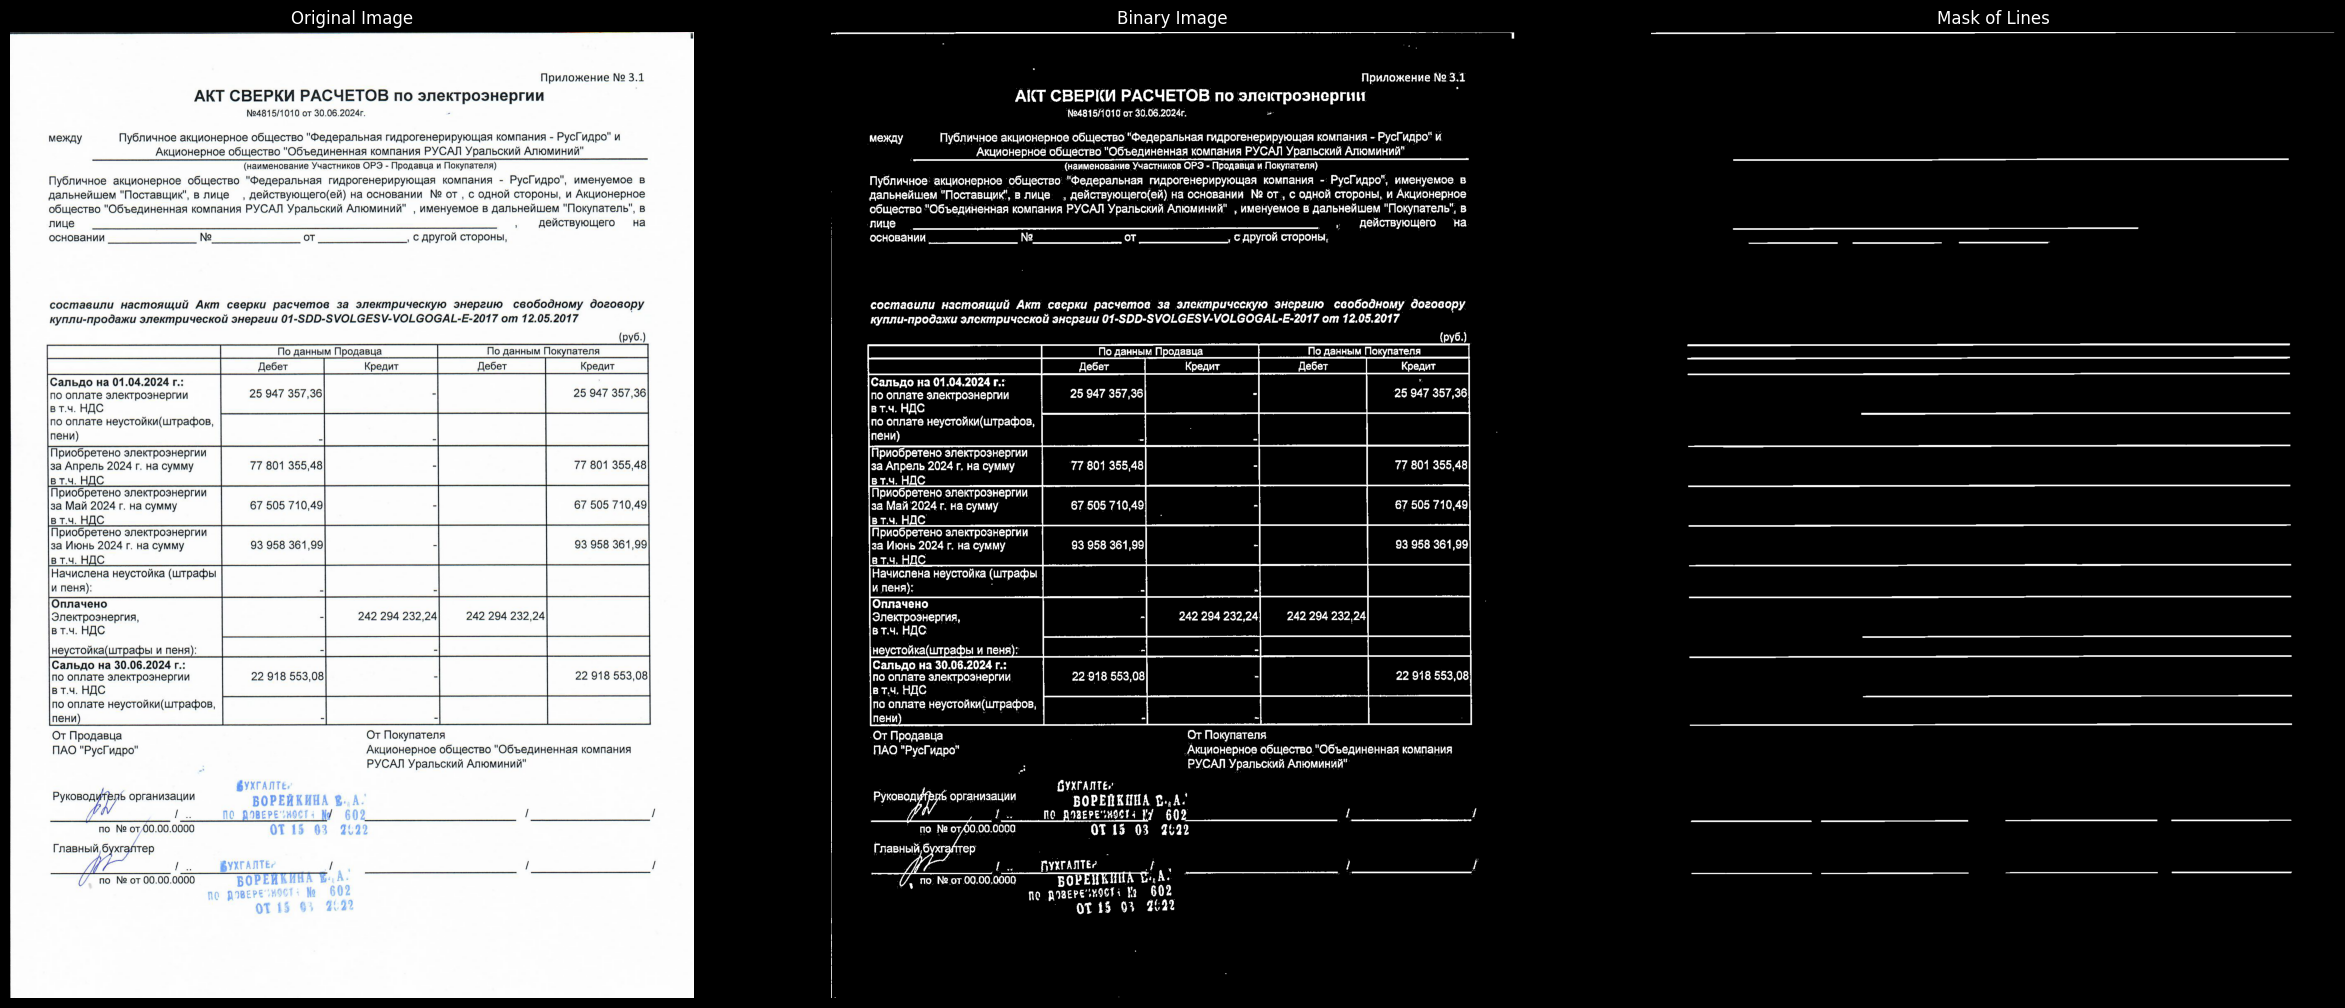

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

blur = cv2.GaussianBlur(l, (1, 1), 0)
gamma = 10.0
lut = (np.arange(256) / 255) ** gamma * 255
gamma_img = cv2.LUT(blur, lut.astype(np.uint8))

bin_img = cv2.adaptiveThreshold(gamma_img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 50)
bin_img = cv2.dilate(bin_img, cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1)), iterations=1)

scale = 50

horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(bin_img.shape[1] / scale), 1))
horizontal_lines = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, horiz_kernel, iterations=2)



plt.figure(figsize=(30, 20))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(bin_img, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(horizontal_lines, cmap="gray")
plt.title("Mask of Lines")
plt.axis("off")
plt.show()

In [207]:
# найдем медиану расстояния между линиями и отфильтруем линии, которые слишком далеко друг от друга
contours, _ = cv2.findContours(horizontal_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
heights = [cv2.boundingRect(cnt)[3] for cnt in contours]
median_height = int(np.median(heights))
print(f"Median height of horizontal lines: {median_height}")

# отбрасываем линии котрые не попадают в median_height
page_height, page_width = img.shape[:2]
filtered_contours = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if abs(h - median_height) < median_height * 0.5:
        filtered_contours.append(cnt)

Median height of horizontal lines: 6


angles: ['-0.01', '-0.00', '-0.03', '-0.29', '-0.01', '0.01', '-0.07', '-0.12', '-0.13', '-0.13', '-0.10', '-0.08', '-0.06', '-0.06', '-0.12', '-0.11', '-0.08', '-0.09', '-0.09', '0.04', '-0.05', '-0.08', '-0.12', '-0.10', '-0.05']
median angle: -0.07776476704537726


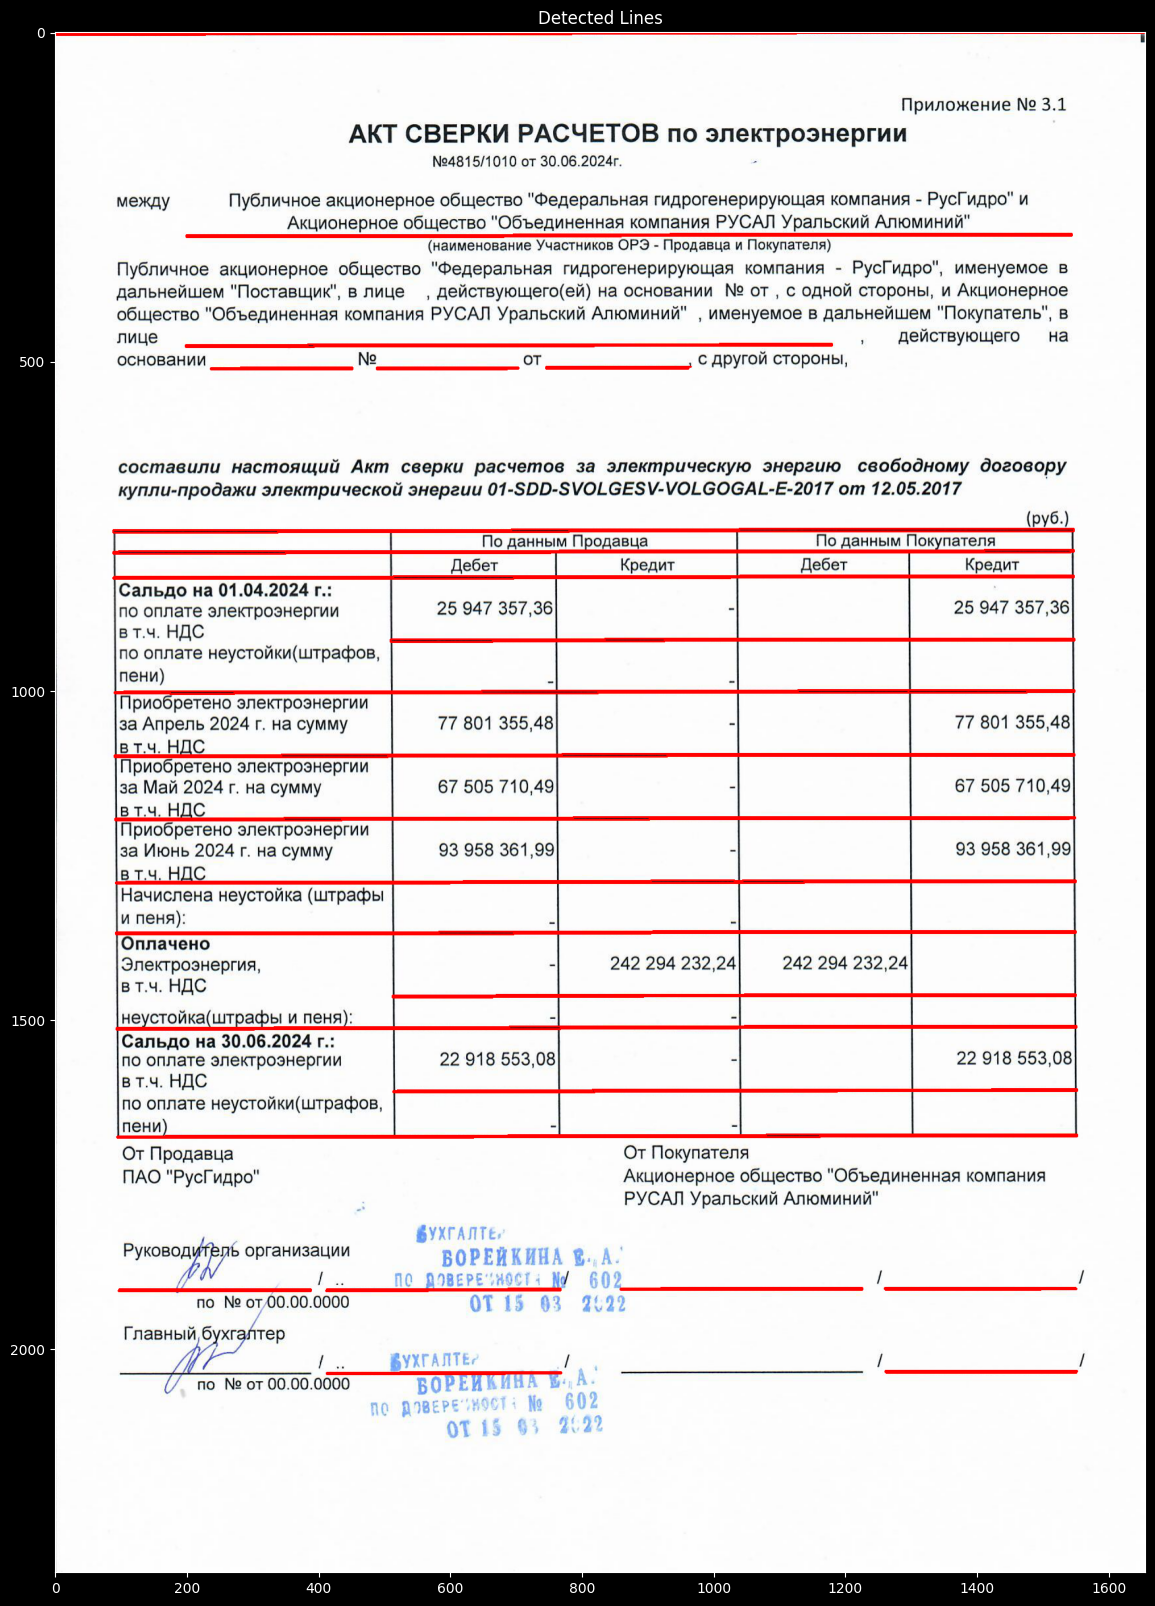

In [208]:
debug_img = img.copy()
def fit_line(cnt):
    [vx, vy, x0, y0] = cv2.fitLine(cnt, cv2.DIST_L2, 0, 0.01, 0.01)
    angle = np.degrees(np.arctan2(vy.item(), vx.item()))
    return vx.item(), vy.item(), x0.item(), y0.item(), angle

angles = []
for cnt in filtered_contours:
    vx, vy, x0, y0, angle = fit_line(cnt)
    angles.append(angle)
    cv2.drawContours(debug_img, [cnt], -1, (255, 0, 0), 2)

median_angle = np.median(angles)
print("angles:", [f"{a:.2f}" for a in angles])
print("median angle:", median_angle)

plt.figure(figsize=(30, 20))
plt.imshow(debug_img)
plt.title("Detected Lines")
plt.show()

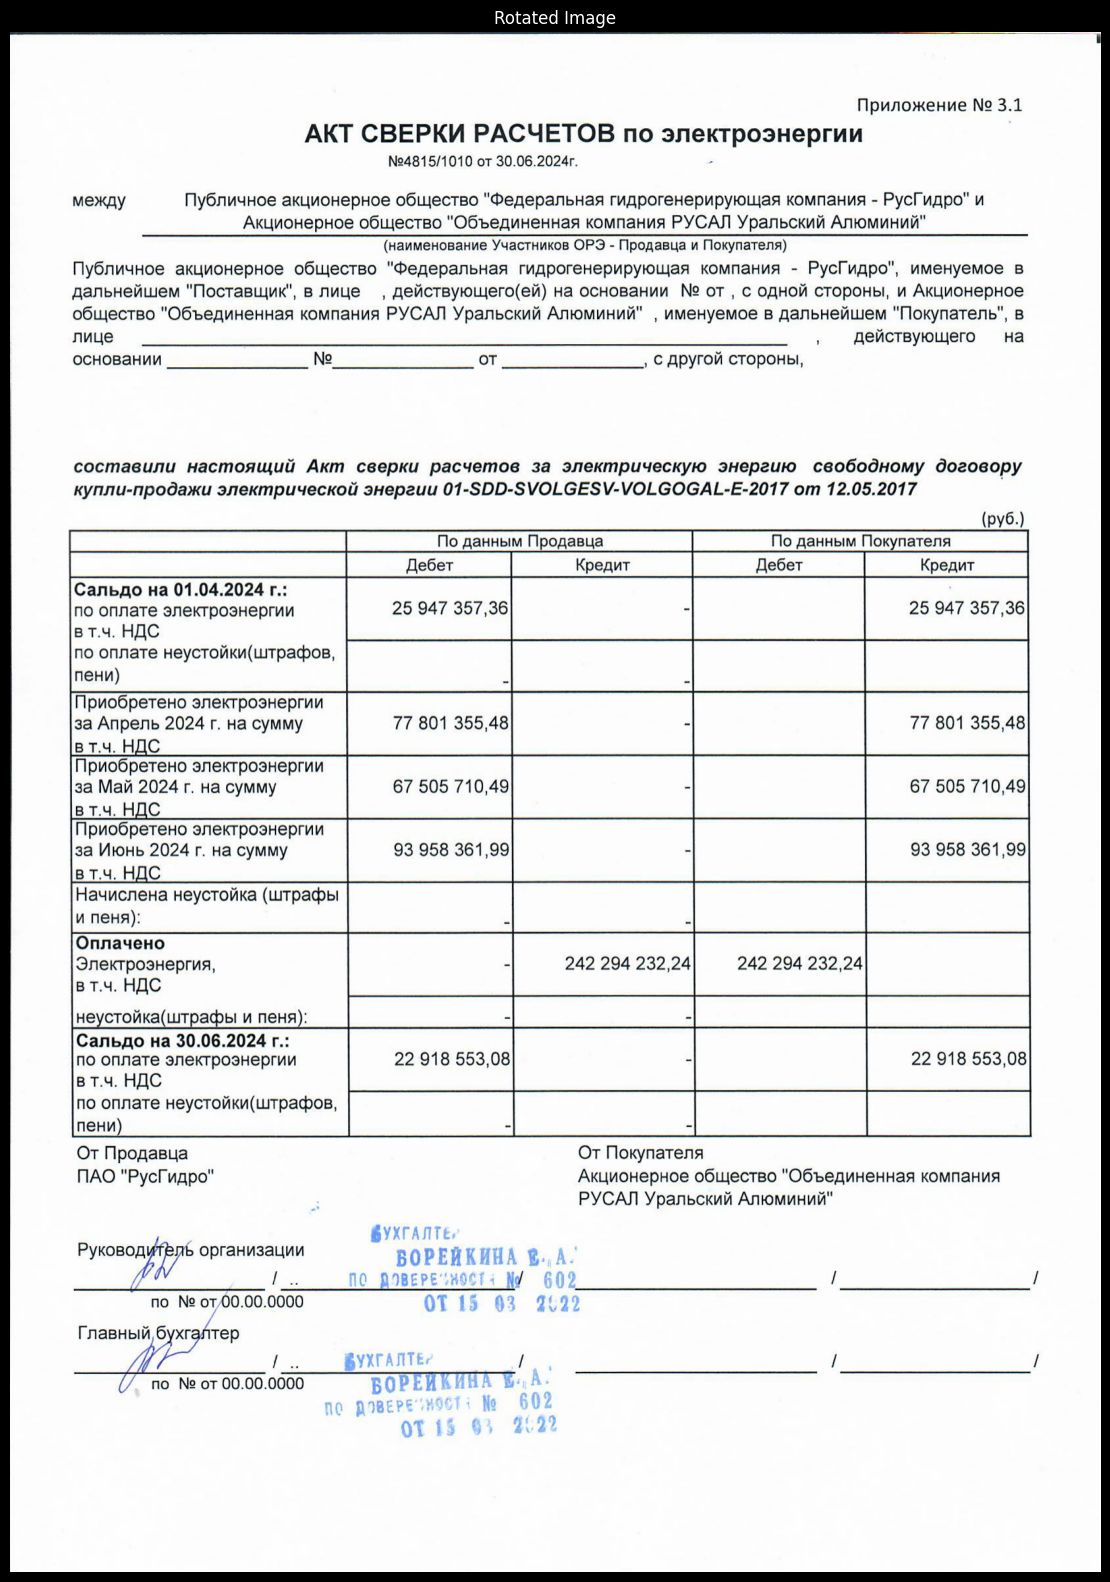

In [209]:
# rotate image by median angle
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, median_angle, 1.0)
rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

plt.figure(figsize=(30, 20))
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")
plt.show()